# Null map performance: false positive rate

When two brain maps are spatially smooth, their parcel-level correlation is not based on
as many independent observations as the parcel count suggests. At brain-realistic spatial
autocorrelation (SA), the effective degrees of freedom drop to roughly **10**, regardless of
whether you have 70 or 400 parcels. A naive permutation test that shuffles parcel values
independently — without preserving spatial structure — therefore produces a null distribution
that is far too narrow, inflating the false positive rate (FPR) to **60–70 %** at α = 0.05.

Spatial null models address this by generating surrogate maps that preserve the SA of the
original data. NiSpace provides several null methods (spin tests, Moran eigenvector
randomization, variogram-matching). Based on benchmarks like the one below, we chose Moran
Spectral Randomization as the default for all parcellation types.

- **cortex-only default**: `"moran"` — Moran Spectral Randomization on the cortical distance matrix
- **combined (cx+sc) default**: `"moran+moran"` — separate Moran runs for cortex and subcortex
- **spin test alternative**: `"cornblath"` (cortex-only, requires surface parcellation)
- **split spin + subcortex Moran**: `"cornblath+moran"` (combined only)

This notebook benchmarks those methods using **Gaussian Random Field (GRF)** maps — synthetic
brain maps with a known, tunable SA. Because the true correlation between independently drawn
GRF pairs is zero by construction, any p < 0.05 is a false positive. The benchmark follows
the methodology of Markello & Misic (2021, *NeuroImage*).

> **Reference:** Markello RD & Misic B (2021). Comparing spatial null models for brain maps.
> *NeuroImage*, 236, 118052. https://doi.org/10.1016/j.neuroimage.2021.118052

> **Note:** this notebook is compute-intensive (several hundred null permutation runs). It is
> designed to be pre-run. To do a quick smoke-test, set `N_PAIRS=20` and `N_PERM=50`.

> **Another note:** we are currently developing a hybrid between Moran Spectral Randomization
> and BrainSMASH's variogram-based method, called `"variomsr"` or `"variomoran"`. The method is 
> experimental and requires further testing.

In [22]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_PAIRS  = 500    # independent GRF pairs per (parcellation × alpha × method) condition
N_PERM   = 1000   # null permutations per permute() call
N_PROC   = -1     # parallel workers (-1 = use all cores)
P_THRESH = 0.05
SEED     = 42
ALPHAS   = [0.0, 1.0, 2.0, 3.0]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sn
from nispace import NiSpace
from nispace.datasets import fetch_reference, fetch_parcellation
from nispace.stats.autocorr import morans_i
from nispace.plotting import brainplot

# function to draw pairs from the GRF dataset
def make_pairs(grf_alpha, n_pairs, rng):
    """Two non-overlapping random samples of n_pairs rows from grf_alpha."""
    n = len(grf_alpha)
    assert n >= 2 * n_pairs, f"Need ≥{2*n_pairs} maps at this alpha; have {n}"
    idx_x = rng.choice(n // 2, size=n_pairs, replace=False)
    idx_y = rng.choice(np.arange(n // 2, n), size=n_pairs, replace=False)
    return grf_alpha.iloc[idx_x], grf_alpha.iloc[idx_y]

## GRF maps: simulating spatial autocorrelation

A Gaussian Random Field with power-law exponent `alpha` has a spatial frequency spectrum
proportional to `|k|^(-alpha)`. At `alpha=0` the map is spatially independent white noise;
as alpha increases the map becomes progressively smoother. Real neuroimaging maps
(PET, transcriptomics, fMRI contrasts parcellated at 200 regions) empirically sit around
`alpha ≈ 1 to 2`.

NiSpace ships pre-parcellated GRF maps for all supported parcellations:
10,000 maps at `alpha=0` and 1,000 each at `alpha=1`, `2`, `3`, all accessible via
`fetch_reference("grf", ..., collection="ByAlpha")`.

WARNING | 14/07/26 20:32:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 14/07/26 20:32:39 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 14/07/26 20:32:39 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 14/07/26 20:32:39 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 14/07/26 20:32:39 | nispace.plotting: brainplot: threshold='auto' → 9.110000246437266e-05
INFO | 14/07/26 20:32:39 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 14/07/26 20:32:39 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.
INFO | 14/07/26 20:32:39 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh

(<Figure size 720x840 with 24 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

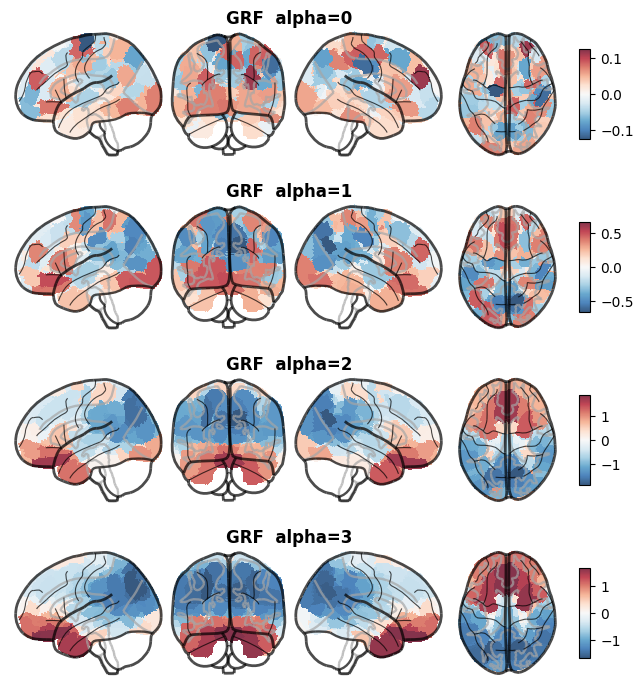

In [23]:
# Load one example map per alpha level and visualize
grf_demo = fetch_reference("grf", parcellation="Yan200", collection="ByAlpha", verbose=False)
sample_maps = [grf_demo.loc[f"alpha-{a:.1f}"].iloc[0] for a in ALPHAS]

brainplot(
    sample_maps,
    title=[f"GRF  alpha={a:.0f}" for a in ALPHAS],
    parcellation="Yan200",
)

## GRF autocorrelation compared to real-world data

The spatial autocorrelation of the GRF maps is defined by their `alpha` value. This does not translate directly to autocorrelation measures used in our null map generation methods to estimate and then simulate autocorrelation. For example, GRF maps that were generated with the same `alpha` parameter will not match a specific Moran's I value, but rather distribute around it.  

Here, we show this empirically and use this information to interpret our benchmark tests below.

INFO | 14/07/26 20:32:53 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 14/07/26 20:32:53 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 14/07/26 20:32:53 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 14/07/26 20:32:53 | nispace.core.parcellation: Lazy-loading dist mat for 'Yan200' in space 'MNI152NLin6Asym'.
GRF alpha=0.0: 1000 maps, min=-0.01, mean=-0.00, max=0.03
GRF alpha=1.0: 1000 maps, min=-0.00, mean=0.04, max=0.13
GRF alpha=2.0: 1000 maps, min=0.02, mean=0.10, max=0.21
GRF alpha=3.0: 1000 maps, min=0.04, mean=0.14, max=0.23
Dataset bigbrain: 13 maps, min=0.02, mean=0.09, max=0.17
Dataset cortexfeatures: 23 maps, min=0.01, mean=0.12, max=0.24
Dataset magicc: 11146 maps, min=0.02, mean=0.13, max=0.23
Dataset mitobrain: 6 maps, min=0.01, mean=0.02, max=0.06
Dataset mrna: 11059 maps, min=-0.01, mean=0.06, max

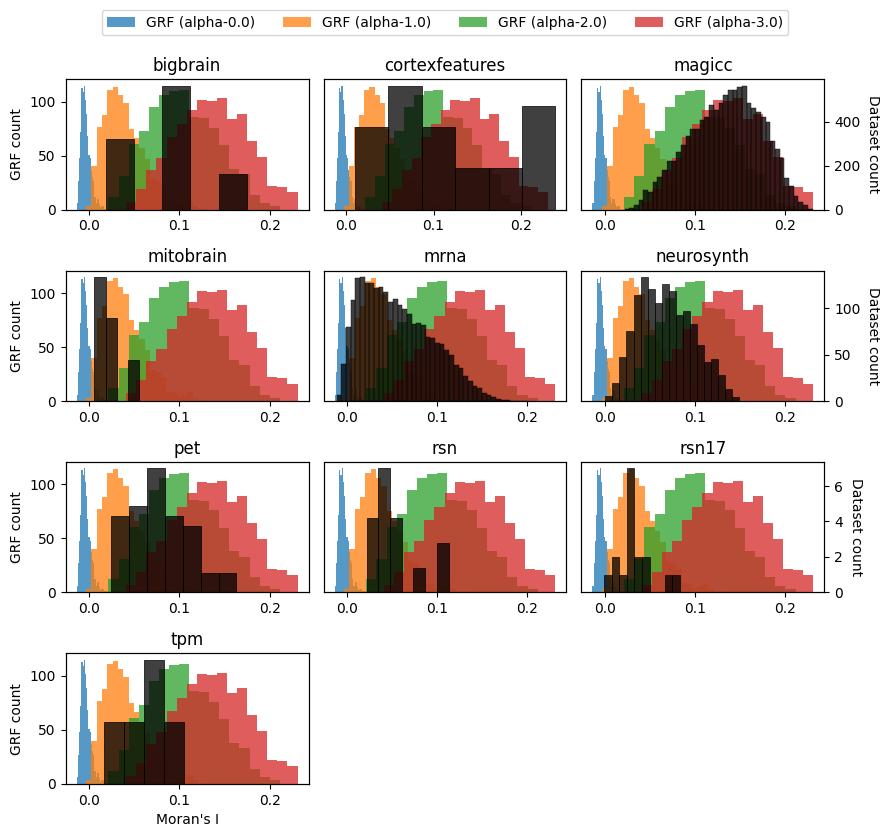

In [24]:
parc = "Yan200"

# fetch distance matrix
dist_mat = fetch_parcellation(parc).get_dist_mat("MNI152NLin6Asym")

# fetch grf values
grf = fetch_reference("grf", parcellation=parc, collection="ByAlpha", verbose=False)

# calculate morans i for grf
grf_moran = {
    alpha: np.array([
        morans_i(m, dist_mat) 
        for _, m in grf.loc[f"alpha-{alpha:.01f}"].iloc[:1000,:].iterrows()
    ])
    for alpha in [0.0, 1.0, 2.0, 3.0]
}

# names of all datasets that have the parcellation
from nispace.datasets import reference_lib
dsets = [dset for dset in reference_lib.keys() 
         if parc in reference_lib[dset]["tab"] and dset not in ["grf"]]

# init plot
ncol = 3
nrow = np.ceil(len(dsets) / ncol).astype(int)
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 2*nrow))

# iterate axes and datasets
for i, ax in enumerate(axes.ravel()):
    if i >= len(dsets):
        ax.set_axis_off()
        continue
    dset = dsets[i]
    ax.set_title(dset)
        
    # plot grf morans i
    for alpha in [0.0, 1.0, 2.0, 3.0]:
        if i == 0:
            print(f"GRF alpha={alpha:.01f}: {grf_moran[alpha].shape[0]} maps, "
                  f"min={grf_moran[alpha].min():.02f}, mean={grf_moran[alpha].mean():.02f}, "
                  f"max={grf_moran[alpha].max():.02f}")
        sn.histplot(grf_moran[alpha], label=f"GRF (alpha-{alpha:.01f})" if i==0 else None, lw=0, ax=ax)

    # calculate and plot distribution of real-world Moran's I values
    df = fetch_reference(dset, parcellation=parc, verbose=False)
    df_moran = np.array([
        morans_i(m, dist_mat) 
        for _, m in df.iterrows()
    ])
    print(f"Dataset {dset}: {df.shape[0]} maps, min={df_moran.min():.02f}, "
          f"mean={df_moran.mean():.02f}, max={df_moran.max():.02f}")
    ax_right = ax.twinx()
    sn.histplot(df_moran, lw=0.5, color="k", ax=ax_right)
    
    # layout
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("GRF count")
    else:
        ax.set_yticks([])
        ax.set_ylabel("")
    if ax.get_subplotspec().is_last_col():
        ax_right.set_ylabel("Dataset count", rotation=-90, va="bottom")
    else:
        ax_right.set_yticks([])
        ax_right.set_ylabel("")
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Moran's I")

fig.legend(loc="lower center", bbox_to_anchor=(0.5, 1), ncol=4)
fig.tight_layout()

## Benchmark design

### Independent pairs → type-I error

For each `(parcellation, alpha, null method)` combination:

1. Sample `N_PAIRS` GRF maps as **X** and a second independent set of `N_PAIRS` GRF maps as **Y** (drawn from non-overlapping seed ranges → `corr(X_i, Y_i) ≈ 0` by construction).
2. Fit a `NiSpace` object with `X` and `Y` and run `colocalize("spearman")`.
   This yields an `(N_PAIRS × N_PAIRS)` Spearman correlation matrix.
3. Run `permute(what="maps", ...)` with the null method under test.
   This yields an `(N_PAIRS × N_PAIRS)` p-value matrix.
4. Extract the diagonal: `np.diag(p_matrix)` — one matched-pair p-value per pair.
5. `FPR = fraction(p < P_THRESH)`. Under a correctly calibrated null this should equal `P_THRESH`.

The 95% confidence interval for `N_PAIRS=500` is:

$$\text{CI} = 0.05 \pm 1.96\sqrt{\frac{0.05 \times 0.95}{500}} \approx [0.031,\ 0.069]$$

### Parcellations

| Parcellation | Type | Default null method |
|---|---|---|
| `DesikanKilliany` | cortex-only | `moran` |
| `DesikanKilliany+Aseg` | cortex + subcortex | `moran+moran` |
| `Yan200` | cortex-only | `moran` |
| `Yan200+TianS2` | cortex + subcortex | `moran+moran` |

### Methods

- `random` — naive shuffle (no SA preservation) — expected to fail badly
- `moran` — Moran spectral randomization on the full distance matrix
- `variomoran` - Moran spectral randomization with variogram-adapted weights matrix
- `cornblath` — spin test (cortex-only only)
- `("moran", "moran")` — split Moran: cortex and subcortex Moran separately (combined only)
- `("variomoran", "variomoran")` - as above, but with variogram-adapted version
- `("cornblath", "moran")` — split: cortex spin + subcortex Moran (combined only)

`*` marks the current NiSpace default

In [ ]:
PARCELLATIONS = {
    "DesikanKilliany": {
        "type": "cx",
        "methods": [
            ("random",    {}, "random"),
            ("moran",     {}, "moran *"), # * = NiSpace default
            ("cornblath", {}, "cornblath"), 
        ],
    },
    "DesikanKilliany+Aseg": {
        "type": "cx+sc",
        "methods": [
            ("random",               {}, "random"),
            ("moran",                {}, "moran"),
            (("moran", "moran"),     {}, "moran+moran *"), # * = NiSpace default
            (("cornblath", "moran"), {}, "cornblath+moran"),
        ],
    },
    "Yan200": {
        "type": "cx",
        "methods": [
            ("random",    {}, "random"),
            ("moran",     {}, "moran *"),
            ("cornblath", {}, "cornblath"),
        ],
    },
    "Yan200+TianS2": {
        "type": "cx+sc",
        "methods": [
            ("random",               {}, "random"),
            ("moran",                {}, "moran"),
            (("moran", "moran"),     {}, "moran+moran *"),
            (("cornblath", "moran"), {}, "cornblath+moran"),
        ],
    },
}

ci_lo = P_THRESH - 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_PAIRS)
ci_hi = P_THRESH + 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_PAIRS)
print(f"95% CI for N_PAIRS={N_PAIRS}: [{ci_lo:.3f}, {ci_hi:.3f}]")

records = []

for parc, cfg in PARCELLATIONS.items():
    print(f"\n{'='*60}\nPARCELLATION: {parc}")
    grf = fetch_reference("grf", parcellation=parc, collection="ByAlpha", verbose=False)

    for alpha in ALPHAS:
        grf_a = grf.loc[f"alpha-{alpha:.1f}"]
        X, Y = make_pairs(grf_a, N_PAIRS, np.random.default_rng(SEED))

        nsp = NiSpace(x=X, y=Y, parcellation=parc, verbose=False, n_proc=N_PROC)
        nsp.fit()
        nsp.colocalize("spearman")

        for maps_method, extra_kw, label in cfg["methods"]:
            nsp.permute(
                what="maps", maps_which="X",
                maps_method=maps_method,
                maps_use_existing=False,
                n_perm=N_PERM,
                seed=SEED,
                verbose=False,
                pooled_p=False,
                **extra_kw,
            )
            p_df = nsp.get_p_values(pooled_p=False)
            assert p_df.shape == (N_PAIRS, N_PAIRS), \
                f"Expected ({N_PAIRS},{N_PAIRS}), got {p_df.shape}"
            p_diag = np.diag(p_df.values)
            fpr = (p_diag < P_THRESH).mean()
            status = "OK" if ci_lo <= fpr <= ci_hi else "!!"
            print(f"  {status} alpha={alpha:.1f}  {label:22s}  FPR={fpr:.3f}")
            records.append({
                "parcellation": parc,
                "type": cfg["type"],
                "alpha": alpha,
                "method": label,
                "fpr": fpr,
            })

results = pd.DataFrame(records)
print("\nDone.")

## Results

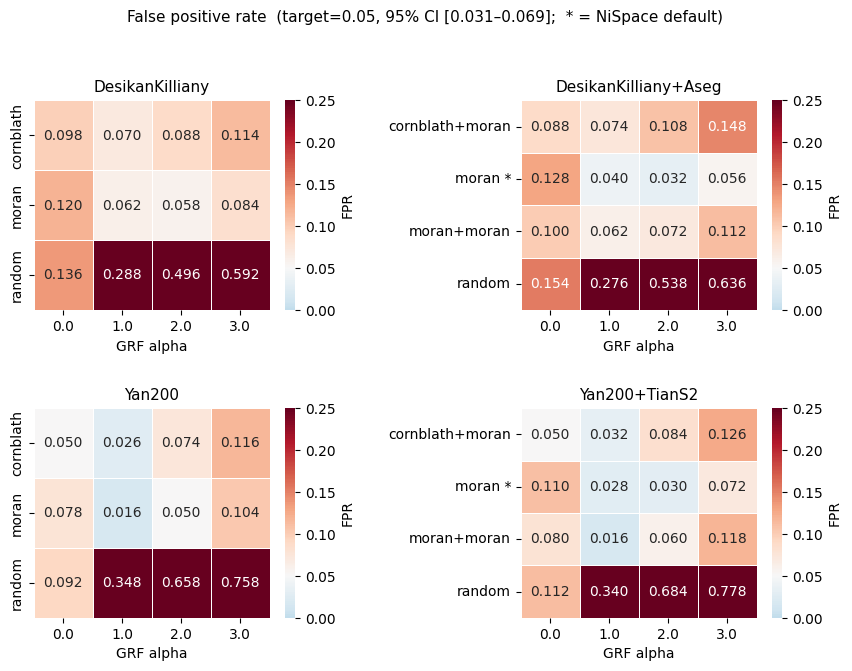

In [26]:
# Heatmap: FPR per (method × alpha) for each parcellation
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

for ax, parc in zip(axes.flat, PARCELLATIONS):
    sub = results[results.parcellation == parc].pivot(
        index="method", columns="alpha", values="fpr")
    sn.heatmap(
        sub, ax=ax,
        annot=True, fmt=".3f",
        cmap="RdBu_r", vmin=0, vmax=0.25, center=P_THRESH,
        cbar_kws={"label": "FPR"},
        linewidths=0.5,
    )
    ax.set_title(parc, fontsize=11)
    ax.set_xlabel("GRF alpha")
    ax.set_ylabel("")

fig.suptitle(
    f"False positive rate  (target={P_THRESH}, 95% CI [{ci_lo:.3f}\u2013{ci_hi:.3f}];  "
    f"* = NiSpace default)",
    fontsize=11,
)
plt.tight_layout(pad=2.5)

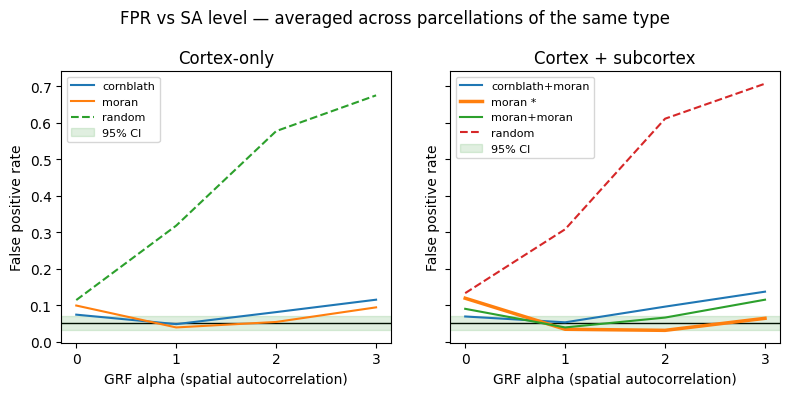

In [27]:
# Line plots: FPR vs alpha, averaged across parcellations of the same type
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

groups = [
    ("cx",   "Cortex-only",          ["DesikanKilliany", "Yan200"]),
    ("cx+sc", "Cortex + subcortex",  ["DesikanKilliany+Aseg", "Yan200+TianS2"]),
]

for ax, (ptype, title, parcs) in zip(axes, groups):
    sub = results[results.parcellation.isin(parcs)]
    for method, grp in sub.groupby("method"):
        mean_fpr = grp.groupby("alpha")["fpr"].mean()
        is_default = "*" in method
        is_random  = method == "random"
        ax.plot(
            mean_fpr.index, mean_fpr.values,
            label=method,
            lw=2.5 if is_default else 1.5,
            ls="--" if is_random else "-",
        )
    ax.axhline(P_THRESH, color="k", lw=1, zorder=0)
    ax.axhspan(ci_lo, ci_hi, alpha=0.12, color="green", zorder=0,
               label="95% CI")
    ax.set_xlabel("GRF alpha (spatial autocorrelation)")
    ax.set_ylabel("False positive rate")
    ax.set_title(title)
    ax.set_xticks(ALPHAS)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("FPR vs SA level — averaged across parcellations of the same type",
             fontsize=12)
plt.tight_layout(w_pad=2.5)

## Interpretation

### Why alpha=0 inflates FPR for *all* null methods

At `alpha=0` the GRF maps are spatially independent white noise — there is near-to-no SA, so
the naive Pearson/Spearman test already gives FPR ≈ 0.05. The SA-preserving null methods 
impose spatial smoothness on their surrogates regardless of whether the input data has any — 
this narrows the null distribution relative to white-noise reality, making the test *anti-conservative*. 
The correction is not needed (and should not be applied) for purely spatially independent data.

### At brain-realistic SA (alpha>0)

The `random` baseline reaches FPR ≈ 60–70 %, confirming that naive permutation is completely invalid 
for spatially autocorrelated brain maps. The NiSpace defaults bring the FPR within or close
to the 95% CI across parcellations.

### Split vs whole-brain for combined parcellations

For combined (cortex + subcortex) parcellations, NiSpace defaults to `moran+moran`: separate
Moran Spectral Randomization runs for cortex and subcortex using their respective precomputed
distance matrices. The split approach has two advantages over a single whole-brain Moran run:
it preserves cortex- and subcortex-specific value distributions in the null (relevant for datasets
such as PET tracers that have systematic cortex-subcortex offsets), and it avoids computing
a combined distance matrix across all parcels. The trade-off is a slightly higher FPR in some
conditions, as visible in the benchmark above.

### Performance problems at high alpha

All methods suffer from inflated FPR at very high alpha. This was also reported by Markello & Misic.
Luckily, most brain data sits at the alpha 0 to 2 range as we could see in the autocorrelation 
histograms above. Care is needed especially for the `"magicc"` gene expression dataset and very 
smooth fMRI-like maps as, for example, a seed-based connectivity or an ICA network map.

## Summary

- Naive permutation inflates FPR to 60–70 % at brain-realistic spatial autocorrelation (alpha>0). **Spatial null correction is essential.**
- NiSpace defaults to `"moran"` for cortex-only and `"moran+moran"` (split) for combined parcellations. Both are calibrated within or close to the 95% CI at brain-realistic SA levels (alpha=1–2).
- SA-preserving nulls are *anti-conservative* at alpha=0 (white noise, no SA). Do not apply them to spatially independent data.
- All methods degrade at very high alpha (≥3). As Markello & Misic also showed, fully controlling FPR at extreme SA is not achievable with current methods.
- Override the default via `permute(..., maps_method=...)`: accepts a string (`"cornblath"`, `"moran"`) or, for split cx+sc, a combined string or tuple (`"moran+moran"`), (`("moran", "moran")`).

**Reference:** Markello RD & Misic B (2021). Comparing spatial null models for brain maps.
*NeuroImage*, 236, 118052. https://doi.org/10.1016/j.neuroimage.2021.118052

---
---

## Moran eigenvector randomization: K sensitivity and variogram-fitted W

The benchmark above uses the default settings for Moran Spectral Randomization in NiSpace 
(`procedure='singleton'`, `n_components=15`). Note that these differ from the defaults in 
BrainSpace, which always uses all eigenvectors. Here we compare the `singleton` procedure across 
a range of K values, and a new **variogram-fitted W** variant.

### The K trade-off

There is no single K that is optimal across all SA levels:

- **Low alpha (white noise):** high K performs better — many sign-flips add noise-like diversity
  to the null, preventing over-imposition of SA.
- **High alpha (smooth maps):** low K performs better — fewer eigenvectors avoids accumulating
  small high-frequency perturbations that inflate correlations. High K is anti-conservative.
- **Sweet spot (alpha ≈ 1–2, realistic brain data):** K ≈ 17–20 for Yan200.

The root cause at high alpha: the input map concentrates variance on only 2–3 MEMs of a 1/d
W matrix, giving an effective null of ~8 distinct maps regardless of K.

### Variogram-fitted W (`fit_variogram=True`)

**Idea**: instead of the fixed geographic W = 1/d, fit the map's own covariance kernel from
its empirical semi-variogram:

```
γ(h) = sill*(1 - exp(-h/range))   ← exponential variogram fit from input map X
W[i,j] = C(d_ij) = sill*exp(-d/range)   ← positive-definite covariance kernel
```

The MEMs derived from this W are the Karhunen-Loève eigenbasis of X's SA structure.
By construction, projection coefficients are spread more evenly across K eigenvectors
(the KL expansion is optimal in mean-squared-error sense) → larger effective K for smooth maps
→ more distinct null maps → better FPR at high alpha.

This is fundamentally different from the `adaptive` procedure (removed): that approach
deflated coefficient magnitudes on the same 1/d MEMs, narrowing null variance → anti-conservative.
Here we change the *basis itself* — no deflation, no reduction in null variance.

Enabled via `maps_fit_variogram=True` in `permute()`. Additional options:
`maps_variogram_kernel` (`'exponential'` / `'gaussian'` / `'spherical'`),  
`maps_variogram_nugget` (fit nugget term),  
`maps_variogram_n_bins` (empirical variogram bins, **default 20**),  
`maps_variogram_threshold` (Moran's I below which to fall back to 1/d W; **default 0**).  

**At alpha=0** (white noise), the variogram fit is unstable → W is effectively random →
inflated FPR. The default `variogram_threshold=0` guards against this: if the map's Moran's I
is ≤ 0 (no positive spatial autocorrelation), the variogram fit is skipped and standard 1/d W
is used instead.

In addition to the FPR heatmap we show the **p-value distribution** for each condition.
Under a correctly calibrated null, p-values should be Uniform(0, 1).

In [ ]:
N_PAIRS_MORAN =  N_PAIRS
N_PERM_MORAN = N_PERM
ALPHAS_MORAN = [0.0, 1.0, 2.0, 3.0]
MORAN_PARCS  = ["Yan200", "Yan200+TianS2"]

MORAN_VARIANTS = [
    # (label, procedure, n_components, fit_variogram)
    ("singleton K=15",      "singleton",    15,     False),
    #("singleton K=17",      "singleton",    17,     False),
    #("singleton K=20",      "singleton",    20,     False),
    ("singleton K=30",      "singleton",    30,     False),
    ("singleton K=50",      "singleton",    50,     False),
    ("singleton K=100",     "singleton",    100,    False),
    ("cov-adapt K=15",      "singleton",    15,     True),
    ("cov-adapt K=30",      "singleton",    30,     True),
    ("cov-adapt K=50",      "singleton",    50,     True),
    ("cov-adapt K=100",     "singleton",    100,    True),
]

ci_lo_m = P_THRESH - 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_PAIRS_MORAN)
ci_hi_m = P_THRESH + 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_PAIRS_MORAN)
print(f"95% CI for N_PAIRS_MORAN={N_PAIRS_MORAN}: [{ci_lo_m:.3f}, {ci_hi_m:.3f}]")

95% CI for N_PAIRS_MORAN=500: [0.031, 0.069]


In [21]:
moran_records = []
moran_pvals   = {}   # (parc, alpha, label) → p_diag array (length N_PAIRS_MORAN)

for parc in MORAN_PARCS:
    print(f"\n{'='*60}\nPARCELLATION: {parc}")
    grf = fetch_reference("grf", parcellation=parc, collection="ByAlpha", verbose=False)

    for alpha in ALPHAS_MORAN:
        grf_a = grf.loc[f"alpha-{alpha:.1f}"]
        X, Y  = make_pairs(grf_a, N_PAIRS_MORAN, np.random.default_rng(SEED))

        nsp = NiSpace(x=X, y=Y, parcellation=parc, verbose=False, n_proc=N_PROC)
        nsp.fit()
        nsp.colocalize("spearman")

        for label, procedure, n_comp, fit_variogram in MORAN_VARIANTS:
            nsp.permute(
                what="maps", maps_which="X",
                maps_method="moran",
                maps_procedure=procedure,
                maps_n_components=n_comp,
                maps_fit_variogram=fit_variogram,
                maps_use_existing=False,
                n_perm=N_PERM_MORAN,
                seed=SEED,
                verbose=False,
                pooled_p=False,
            )
            p_df   = nsp.get_p_values(pooled_p=False)
            p_diag = np.diag(p_df.values)
            fpr    = (p_diag < P_THRESH).mean()
            status = "OK" if ci_lo_m <= fpr <= ci_hi_m else "!!"
            print(f"  {status} alpha={alpha:.1f}  {label:22s}  FPR={fpr:.3f}")

            moran_records.append({
                "parcellation": parc, "alpha": alpha, "label": label,
                "procedure": procedure, "K": n_comp,
                "fit_variogram": fit_variogram, "fpr": fpr,
            })
            moran_pvals[(parc, alpha, label)] = p_diag

moran_results = pd.DataFrame(moran_records)
print("\nDone.")


PARCELLATION: Yan200
  !! alpha=0.0  singleton K=15          FPR=0.078
  !! alpha=0.0  singleton K=30          FPR=0.074
  OK alpha=0.0  singleton K=50          FPR=0.068
  OK alpha=0.0  singleton K=100         FPR=0.068
  !! alpha=0.0  cov-adapt K=15          FPR=0.078
  !! alpha=0.0  cov-adapt K=30          FPR=0.078
  !! alpha=0.0  cov-adapt K=50          FPR=0.070
  !! alpha=0.0  cov-adapt K=100         FPR=0.072
  !! alpha=1.0  singleton K=15          FPR=0.016
  !! alpha=1.0  singleton K=30          FPR=0.026
  OK alpha=1.0  singleton K=50          FPR=0.038
  !! alpha=1.0  singleton K=100         FPR=0.076
  !! alpha=1.0  cov-adapt K=15          FPR=0.016
  !! alpha=1.0  cov-adapt K=30          FPR=0.030
  OK alpha=1.0  cov-adapt K=50          FPR=0.046
  !! alpha=1.0  cov-adapt K=100         FPR=0.084
  OK alpha=2.0  singleton K=15          FPR=0.050
  !! alpha=2.0  singleton K=30          FPR=0.082
  !! alpha=2.0  singleton K=50          FPR=0.088


/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  !! alpha=2.0  singleton K=100         FPR=0.116
  OK alpha=2.0  cov-adapt K=15          FPR=0.052
  OK alpha=2.0  cov-adapt K=30          FPR=0.066
  !! alpha=2.0  cov-adapt K=50          FPR=0.082
  !! alpha=2.0  cov-adapt K=100         FPR=0.106
  !! alpha=3.0  singleton K=15          FPR=0.104
  !! alpha=3.0  singleton K=30          FPR=0.138
  !! alpha=3.0  singleton K=50          FPR=0.146
  !! alpha=3.0  singleton K=100         FPR=0.152
  !! alpha=3.0  cov-adapt K=15          FPR=0.100
  !! alpha=3.0  cov-adapt K=30          FPR=0.120
  !! alpha=3.0  cov-adapt K=50          FPR=0.134
  !! alpha=3.0  cov-adapt K=100         FPR=0.184

PARCELLATION: Yan200+TianS2
  !! alpha=0.0  singleton K=15          FPR=0.110
  !! alpha=0.0  singleton K=30          FPR=0.070
  OK alpha=0.0  singleton K=50          FPR=0.064
  !! alpha=0.0  singleton K=100         FPR=0.070
  !! alpha=0.0  cov-adapt K=15          FPR=0.118
  !! alpha=0.0  cov-adapt K=30          FPR=0.084
  !! alpha=0.0  cov-a

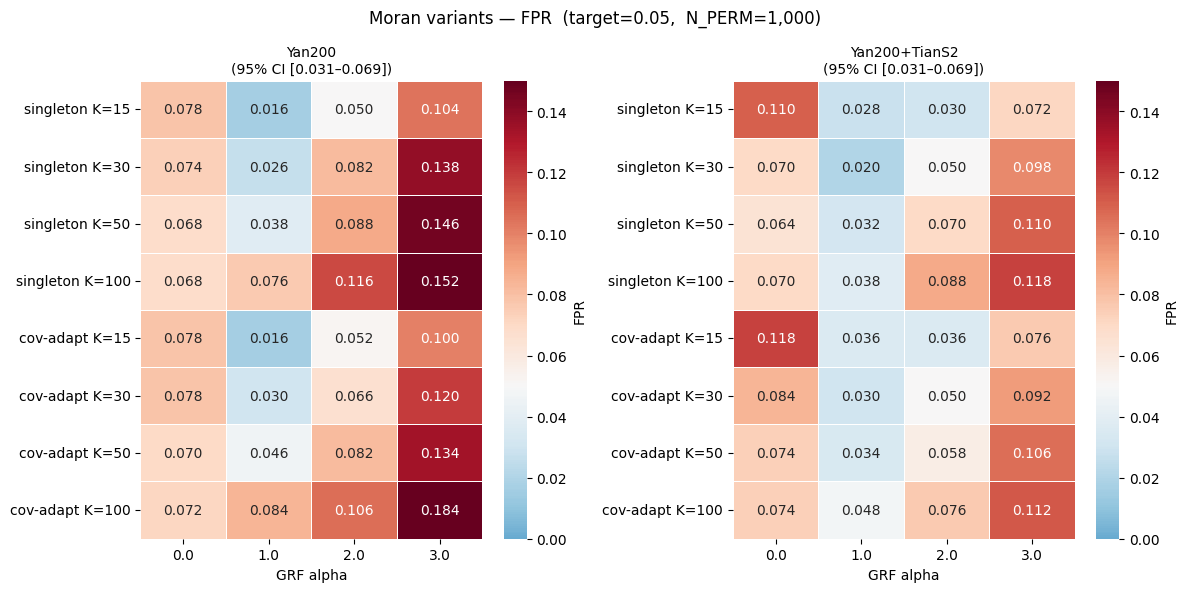

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, parc in zip(axes, MORAN_PARCS):
    sub = moran_results[moran_results.parcellation == parc].pivot(
        index="label", columns="alpha", values="fpr"
    )
    sub = sub.loc[[lbl for lbl, *_ in MORAN_VARIANTS]]
    sn.heatmap(
        sub, ax=ax,
        annot=True, fmt=".3f",
        cmap="RdBu_r", vmin=0, vmax=0.15, center=P_THRESH,
        cbar_kws={"label": "FPR"},
        linewidths=0.5,
    )
    ax.set_title(f"{parc}\n(95% CI [{ci_lo_m:.3f}–{ci_hi_m:.3f}])", fontsize=10)
    ax.set_xlabel("GRF alpha")
    ax.set_ylabel("")

fig.suptitle(
    f"Moran variants — FPR  (target={P_THRESH},  N_PERM={N_PERM_MORAN:,})",
    fontsize=12,
)
plt.tight_layout()


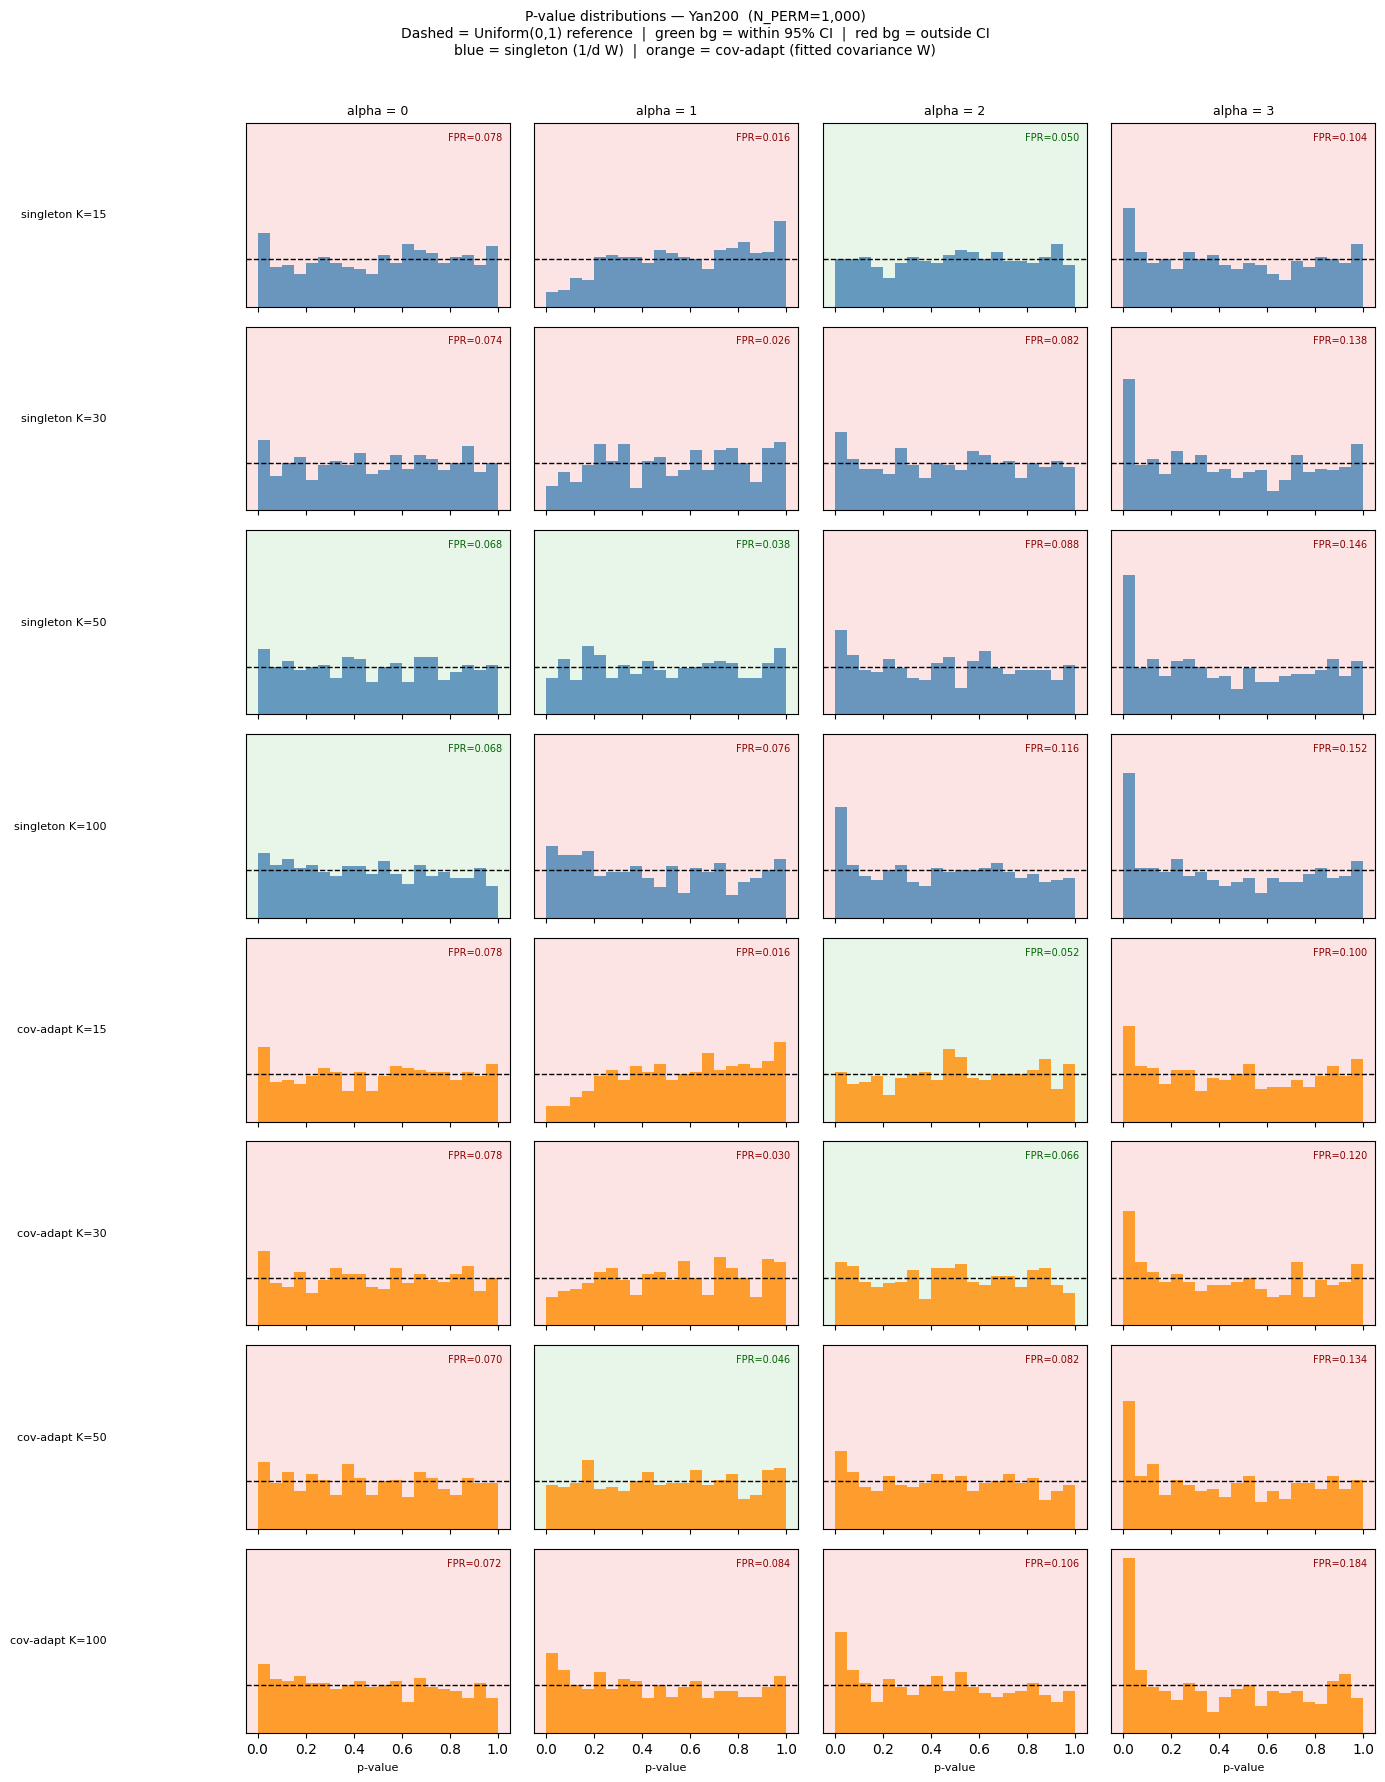

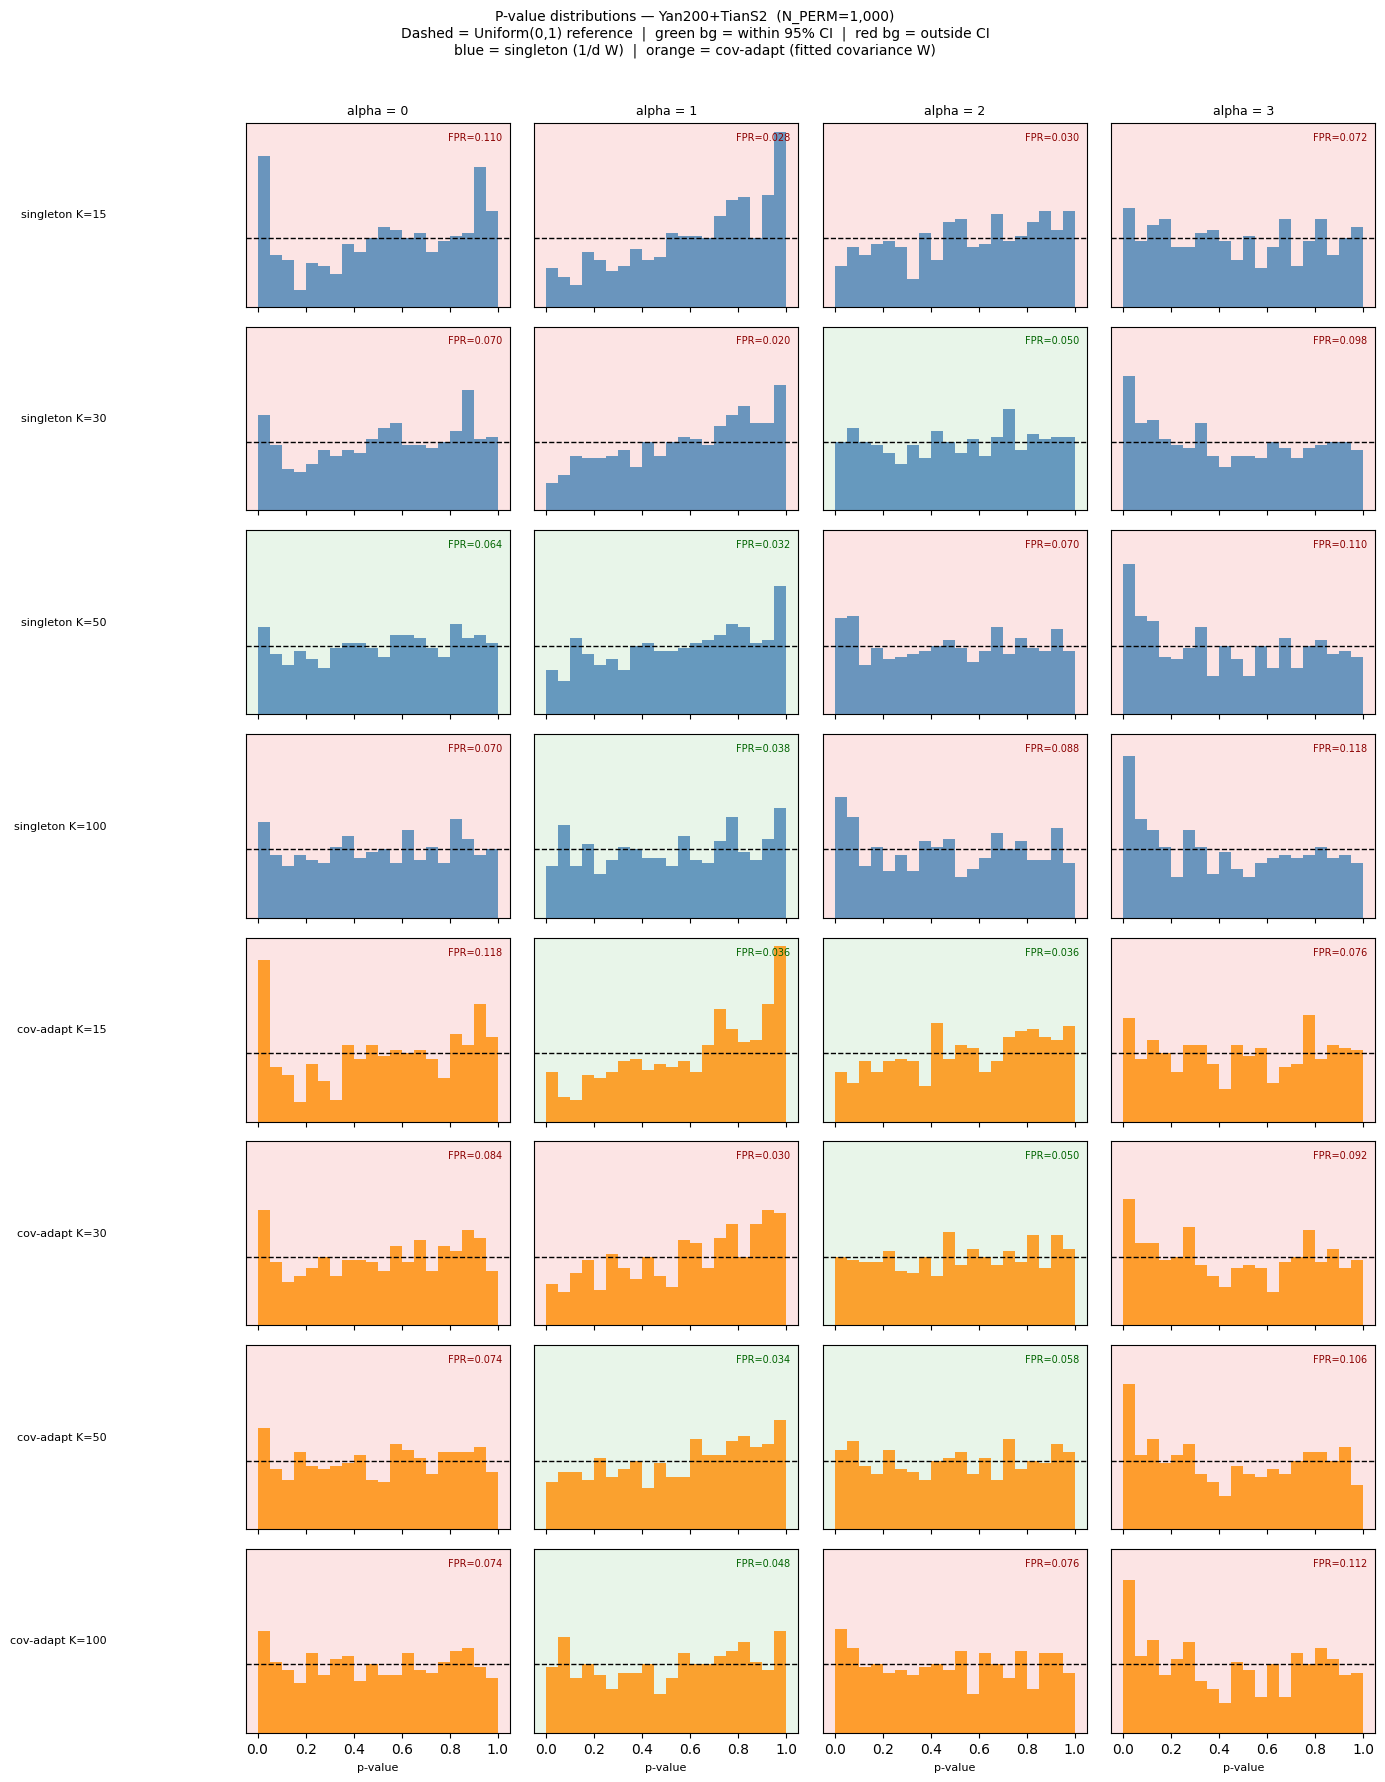

In [29]:
n_methods = len(MORAN_VARIANTS)
n_alphas  = len(ALPHAS_MORAN)

for parc in MORAN_PARCS:
    fig, axes = plt.subplots(
        n_methods, n_alphas,
        figsize=(3.5 * n_alphas, 2.2 * n_methods),
        sharex=True, sharey=True,
    )
    for row, (label, procedure, n_comp, cov_adapt) in enumerate(MORAN_VARIANTS):
        for col, alpha in enumerate(ALPHAS_MORAN):
            ax  = axes[row, col]
            pvs = moran_pvals[(parc, alpha, label)]
            fpr = moran_results.loc[
                (moran_results.parcellation == parc) &
                (moran_results.alpha == alpha) &
                (moran_results.label == label), "fpr"
            ].values[0]
            in_ci = ci_lo_m <= fpr <= ci_hi_m
            color = "darkorange" if cov_adapt else "steelblue"
            ax.set_facecolor("#e8f5e9" if in_ci else "#fce4e4")
            ax.hist(pvs, bins=20, range=(0, 1), density=True,
                    color=color, edgecolor="none", alpha=0.8)
            ax.axhline(1.0, color="k", lw=1, ls="--")
            ax.text(0.97, 0.95, f"FPR={fpr:.3f}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=7,
                    color="darkgreen" if in_ci else "darkred")
            if row == 0:
                ax.set_title(f"alpha = {alpha:.0f}", fontsize=9)
            if col == 0:
                ax.set_ylabel(label, fontsize=8, rotation=0,
                              ha="right", va="center", labelpad=100)
            ax.set_yticks([])
            if row == n_methods - 1:
                ax.set_xlabel("p-value", fontsize=8)

    fig.suptitle(
        f"P-value distributions — {parc}  (N_PERM={N_PERM_MORAN:,})\n"
        "Dashed = Uniform(0,1) reference  |  green bg = within 95% CI  |  red bg = outside CI\n"
        "blue = singleton (1/d W)  |  orange = cov-adapt (fitted covariance W)",
        fontsize=10, y=1.01,
    )
    plt.tight_layout()
    plt.show()